In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline

# Загружаем данные

In [3]:
df = sm.datasets.get_rdataset("mlc_churn", 'modeldata').data
df.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,no
1,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
2,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
3,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,no
4,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no


- churn: A categorical/binary variable indicating whether the customer left the company (yes or no)
- state: The US state where the customer resides (categorical)
- account_length: The number of days or months the account has been active (numeric)
- area_code: The telephone area code of the customer (numeric)
- international_plan: Explains if the customer has an international calling plan (yes or no)
- voice_mail_plan: Explains if the customer has a voicemail plan (yes or no)
- number_vmail_messages: The total number of voicemail messages the customer has sent or received (numeric)
- The usage attributes track both time spent on calls (minutes), the volume of calls (calls), and the billing amount (charge), broken down across day, evening, night, and international markets

# 1. Подготовка данных

In [4]:
df['target'] = np.where(df["churn"] == 'yes', 1, 0)
df.head()

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,...,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn,target
0,KS,128,area_code_415,no,yes,25,265.1,110,45.07,197.4,...,16.78,244.7,91,11.01,10.0,3,2.70,1,no,0
1,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,...,16.62,254.4,103,11.45,13.7,3,3.70,1,no,0
2,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,...,10.30,162.6,104,7.32,12.2,5,3.29,0,no,0
3,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,...,5.26,196.9,89,8.86,6.6,7,1.78,2,no,0
4,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,...,12.61,186.9,121,8.41,10.1,3,2.73,3,no,0


In [6]:
# Создаем новую переменную как сумму всех платежей
df["total_charge"] = df[[col for col in df.columns if col.find("charge")!= -1]].sum(axis = 1)

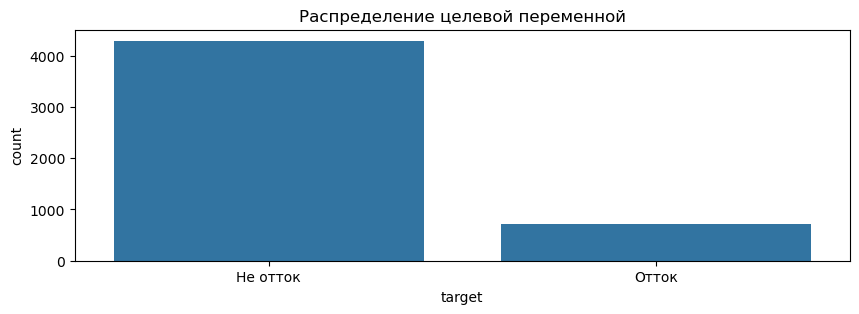

In [7]:
fig, ax = plt.subplots(1,1, figsize = (10,3))
sns.barplot(df['target'].value_counts())
ax.set_title(f'Распределение целевой переменной')
ax.xaxis.set_ticks(range(2))
ax.set_xticklabels(["Не отток", "Отток"])
plt.show()

# 2. Изучаем связь целевой переменной и предикторов

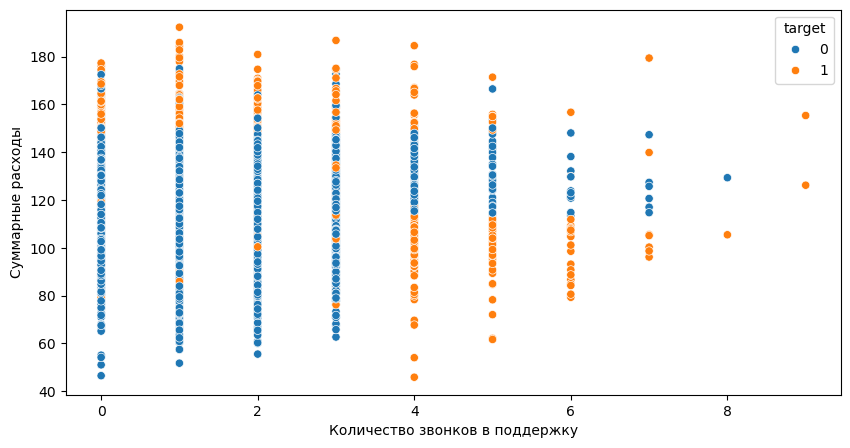

In [11]:
fig, ax = plt.subplots(1,1, figsize = (10, 5))
sns.scatterplot(x = "number_customer_service_calls", y = "total_charge", data = df, hue = "target", ax = ax)
ax.set_xlabel("Количество звонков в поддержку")
ax.set_ylabel("Суммарные расходы")
plt.show()

# 3. Обучим модель KNN

In [32]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train, n_neighbors=3):
    model = KNeighborsClassifier(n_neighbors)
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test, proba = False):
    if proba:
        return model.predict_proba(X_test)[:, 1]
    else:
        return model.predict(X_test)

def visualize_prediction(y_true, y_pred, model):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot()
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Accuracy: ', accuracy_score(y_true, y_pred)),
    print('Precision: ', precision_score(y_true, y_pred))
    print('Recall: ', recall_score(y_true, y_pred))
    print('F1: ', f1_score(y_true, y_pred))
    print('ROC-AUC: ', roc_auc_score(y_true, y_pred))

#### Простая модель KNN с двумя предикторами без масштабирования

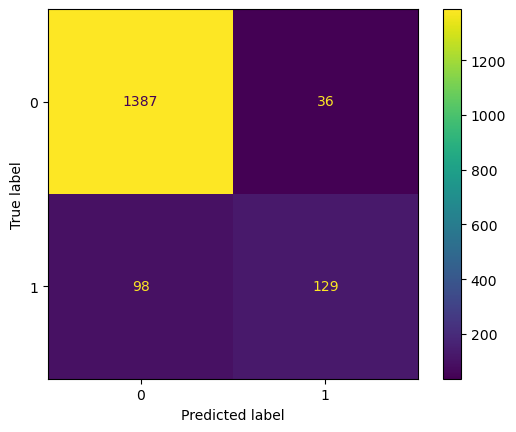

Среднее значение Y:  0.13757575757575757
Accuracy:  0.9187878787878788
Precision:  0.7818181818181819
Recall:  0.5682819383259912
F1:  0.6581632653061225
ROC-AUC:  0.7714916367666498


In [33]:
target_col = ["target"]
features_col = ["total_charge", "number_customer_service_calls"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train.values.ravel())
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

#### Простая модель KNN с двумя предикторами c масштабированием

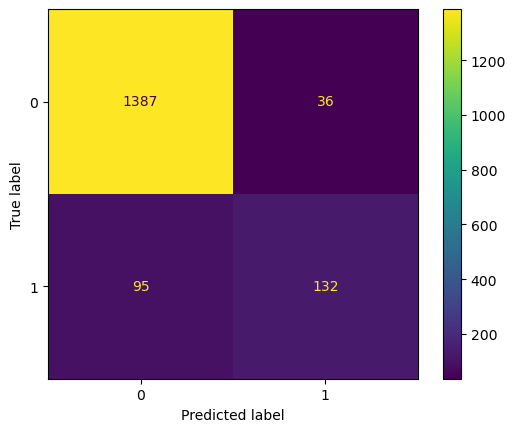

Среднее значение Y:  0.13757575757575757
Accuracy:  0.9206060606060606
Precision:  0.7857142857142857
Recall:  0.5814977973568282
F1:  0.6683544303797468
ROC-AUC:  0.7780995662820683


In [34]:
target_col = ["target"]
features_col = ["total_charge", "number_customer_service_calls"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = train_model(X_train_scaled, y_train.values.ravel())
y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

#### Простая модель KNN с двумя предикторами c масштабированием и N = 5

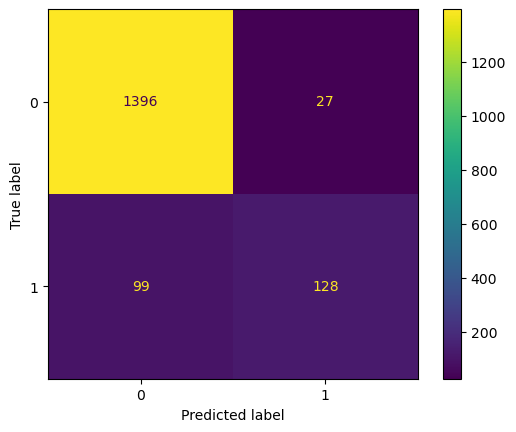

Среднее значение Y:  0.13757575757575757
Accuracy:  0.9236363636363636
Precision:  0.8258064516129032
Recall:  0.5638766519823789
F1:  0.6701570680628273
ROC-AUC:  0.7724513266939301


In [35]:
target_col = ["target"]
features_col = ["total_charge", "number_customer_service_calls"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = train_model(X_train_scaled, y_train.values.ravel(), n_neighbors=5)
y_pred = get_predictions(model, X_test_scaled)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)

#### Простая модель KNN с двумя предикторами c масштабированием, N = 5 и изменяемым значением порога

In [36]:
def get_prediction_from_proba(y_proba, threshold = 0.5):
    return (y_proba > threshold)*1

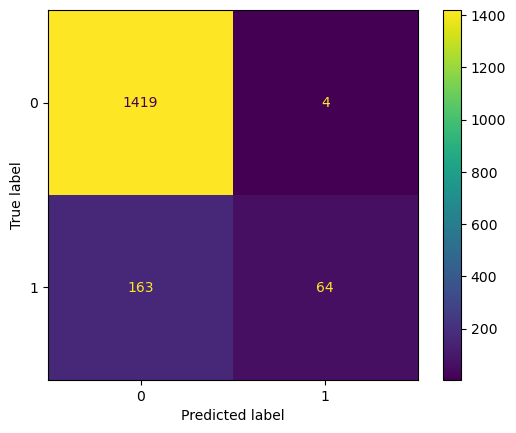

Среднее значение Y:  0.13757575757575757
Accuracy:  0.8987878787878788
Precision:  0.9411764705882353
Recall:  0.28193832599118945
F1:  0.43389830508474575
ROC-AUC:  0.639563681618223


In [38]:
target_col = ["target"]
features_col = ["total_charge", "number_customer_service_calls"]
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = train_model(X_train_scaled, y_train.values.ravel(), n_neighbors=5)
y_proba = get_predictions(model, X_test_scaled, proba = True)
y_pred = get_prediction_from_proba(y_proba, threshold = 0.8)
visualize_prediction(y_test, y_pred, model)
show_metrics(y_test, y_pred)